# Predicting Electricity Consumption and Detecting Anomalous Energy Use

This notebook develops a simple machine-learning workflow for university-building electricity data.

We will work mainly with the **GEPIII / ASHRAE Energy Prediction** dataset.

The notebook has two main phases:

**Phase 1 — Electricity prediction**
- Clean and prepare the data
- Explore electricity consumption
- Create simple time, building and weather features
- Build a **Linear Regression base model**
- Build **Random Forest** and **Gradient Boosting proposed models**
- Compare the models using MAE, RMSE and R²

**Phase 2 — Anomaly detection**
- Calculate prediction residuals
- Identify unusually large residuals
- Rank unusual observations by their prediction error

The official GEPIII test set is kept separate because its actual electricity readings are not provided.

## 1. Import libraries

We use common Python libraries and keep the code simple so each step is easy to follow.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load the GEPIII data

Put the six GEPIII files in the same folder as this notebook before running it.

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

building_metadata = pd.read_csv("building_metadata.csv")

weather_train = pd.read_csv("weather_train.csv")
weather_test = pd.read_csv("weather_test.csv")

## 3. Structure of all the data

In [3]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Building metadata shape:", building_metadata.shape)
print("Weather train shape:", weather_train.shape)
print("Weather test shape:", weather_test.shape)

Train shape: (20216100, 4)
Test shape: (41697600, 4)
Building metadata shape: (1449, 6)
Weather train shape: (139773, 9)
Weather test shape: (277243, 9)


In [4]:
print(train.head())
print(train.columns)

print(building_metadata.head())
print(weather_train.head())

   building_id  meter            timestamp  meter_reading
0            0      0  2016-01-01 00:00:00            0.0
1            1      0  2016-01-01 00:00:00            0.0
2            2      0  2016-01-01 00:00:00            0.0
3            3      0  2016-01-01 00:00:00            0.0
4            4      0  2016-01-01 00:00:00            0.0
Index(['building_id', 'meter', 'timestamp', 'meter_reading'], dtype='str')
   site_id  building_id primary_use  square_feet  year_built  floor_count
0        0            0   Education         7432      2008.0          NaN
1        0            1   Education         2720      2004.0          NaN
2        0            2   Education         5376      1991.0          NaN
3        0            3   Education        23685      2002.0          NaN
4        0            4   Education       116607      1975.0          NaN
   site_id            timestamp  air_temperature  cloud_coverage  \
0        0  2016-01-01 00:00:00             25.0             6.0 

## 4. Select electricity data

GEPIII contains several meter types. Meter `0` represents electricity so we select that for our project

In [5]:
electricity = train[train["meter"] == 0].copy()

print("Electricity data shape:", electricity.shape)
print(electricity.head())

Electricity data shape: (12060910, 4)
   building_id  meter            timestamp  meter_reading
0            0      0  2016-01-01 00:00:00            0.0
1            1      0  2016-01-01 00:00:00            0.0
2            2      0  2016-01-01 00:00:00            0.0
3            3      0  2016-01-01 00:00:00            0.0
4            4      0  2016-01-01 00:00:00            0.0


## 5. Convert timestamps

In [6]:
electricity["timestamp"] = pd.to_datetime(electricity["timestamp"])

weather_train["timestamp"] = pd.to_datetime(weather_train["timestamp"])
weather_test["timestamp"] = pd.to_datetime(weather_test["timestamp"])

test["timestamp"] = pd.to_datetime(test["timestamp"])

## 6. Data cleaning

In [7]:
# Check exact duplicate rows
print("Exact duplicate rows:", electricity.duplicated().sum())

# Check duplicate building/timestamp/meter records
print("Duplicate building-timestamp-meter rows:", electricity.duplicated( subset=["building_id", "timestamp", "meter"]).sum())

# Check negative readings
print("Negative meter readings:", (electricity["meter_reading"] < 0).sum())

# Check missing target readings
print("Missing meter readings:", electricity["meter_reading"].isna().sum())

Exact duplicate rows: 0
Duplicate building-timestamp-meter rows: 0
Negative meter readings: 0
Missing meter readings: 0


### 6.1 Remove duplicate records

In [ ]:
before = len(electricity)

# Remove exact duplicates
electricity = electricity.drop_duplicates().copy()

# Remove duplicate building/timestamp/meter observations
electricity = electricity.drop_duplicates(subset=["building_id", "timestamp", "meter"],keep="first").copy()

print("Rows removed because of duplicates:", before - len(electricity))
print("Rows remaining:", len(electricity))

Rows removed because of duplicates: 0
Rows remaining: 12060910


### 6.2 Handle invalid negative readings

In [9]:
before = len(electricity)

electricity = electricity[electricity["meter_reading"] >= 0].copy()

print("Negative readings removed:", before - len(electricity))
print("Rows remaining:", len(electricity))

Negative readings removed: 0
Rows remaining: 12060910


### 6.3 Handle missing target readings

In [10]:
before = len(electricity)

electricity = electricity.dropna(subset=["meter_reading"]).copy()

print("Rows removed because target was missing:", before - len(electricity))
print("Missing target values remaining:", electricity["meter_reading"].isna().sum())

Rows removed because target was missing: 0
Missing target values remaining: 0


## 7. Create basic time features

Electricity use can change depending on the hour, day of the week, month and whether it is a weekend.

In [11]:
electricity["hour"] = electricity["timestamp"].dt.hour
electricity["dayofweek"] = electricity["timestamp"].dt.dayofweek
electricity["month"] = electricity["timestamp"].dt.month
electricity["weekend"] = (electricity["dayofweek"] >= 5).astype(int)

## 8. Exploratory data analysis

These plots help us understand the electricity data before modelling.

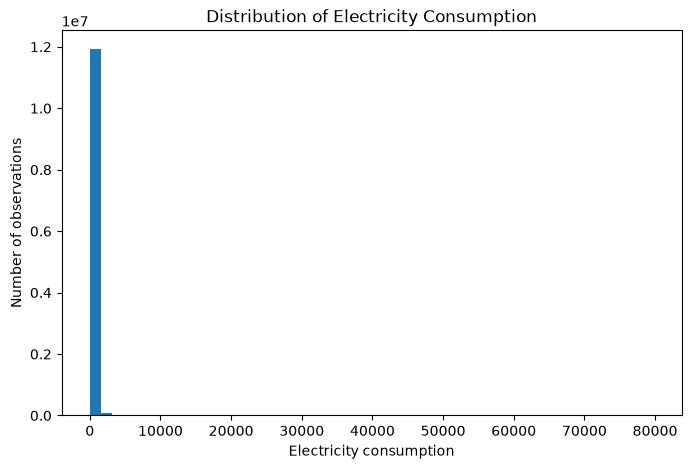

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(electricity["meter_reading"], bins=50)
plt.xlabel("Electricity consumption")
plt.ylabel("Number of observations")
plt.title("Distribution of Electricity Consumption")
plt.show()

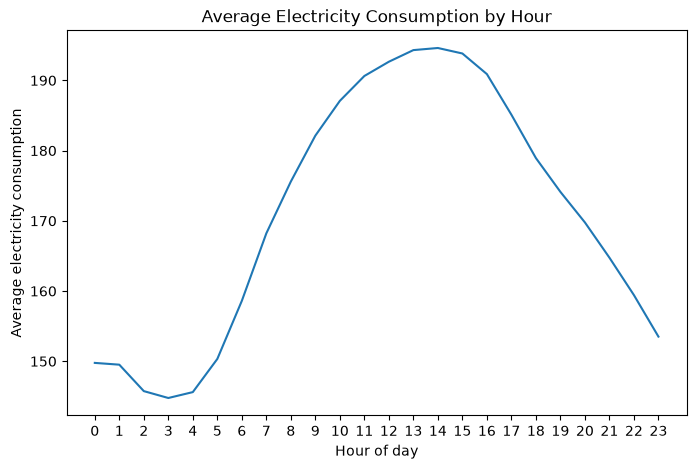

In [13]:
hourly_average = electricity.groupby("hour")["meter_reading"].mean()

plt.figure(figsize=(8, 5))
plt.plot(hourly_average.index, hourly_average.values)
plt.xlabel("Hour of day")
plt.ylabel("Average electricity consumption")
plt.title("Average Electricity Consumption by Hour")
plt.xticks(range(24))
plt.show()

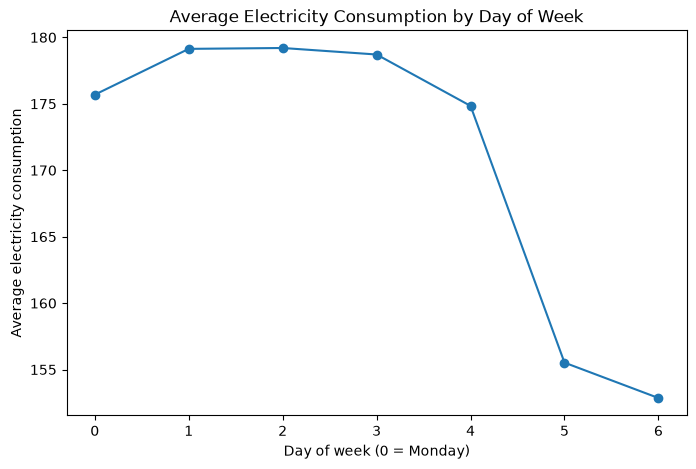

In [14]:
weekday_average = electricity.groupby("dayofweek")["meter_reading"].mean()

plt.figure(figsize=(8, 5))
plt.plot(weekday_average.index, weekday_average.values, marker="o")
plt.xlabel("Day of week (0 = Monday)")
plt.ylabel("Average electricity consumption")
plt.title("Average Electricity Consumption by Day of Week")
plt.show()

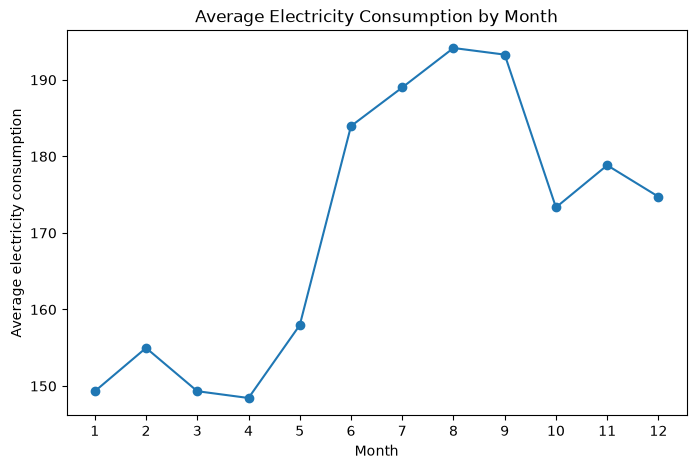

In [15]:
monthly_average = electricity.groupby("month")["meter_reading"].mean()

plt.figure(figsize=(8, 5))
plt.plot(monthly_average.index, monthly_average.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Average electricity consumption")
plt.title("Average Electricity Consumption by Month")
plt.xticks(range(1, 13))
plt.show()

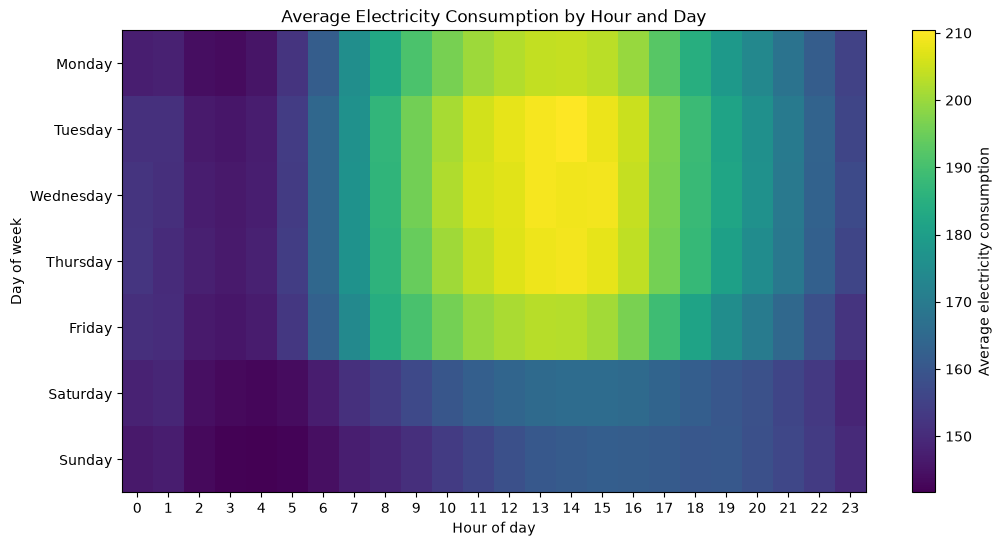

In [16]:
# Average electricity consumption by hour and day of week

heatmap_data = electricity.pivot_table(values="meter_reading", index="dayofweek", columns="hour", aggfunc="mean")
# Rename the days for easier reading
heatmap_data.index = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
plt.figure(figsize=(12, 6))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Average electricity consumption")
plt.xlabel("Hour of day")
plt.ylabel("Day of week")
plt.title("Average Electricity Consumption by Hour and Day")
plt.xticks(range(24))
plt.yticks(range(7), heatmap_data.index)
plt.show()

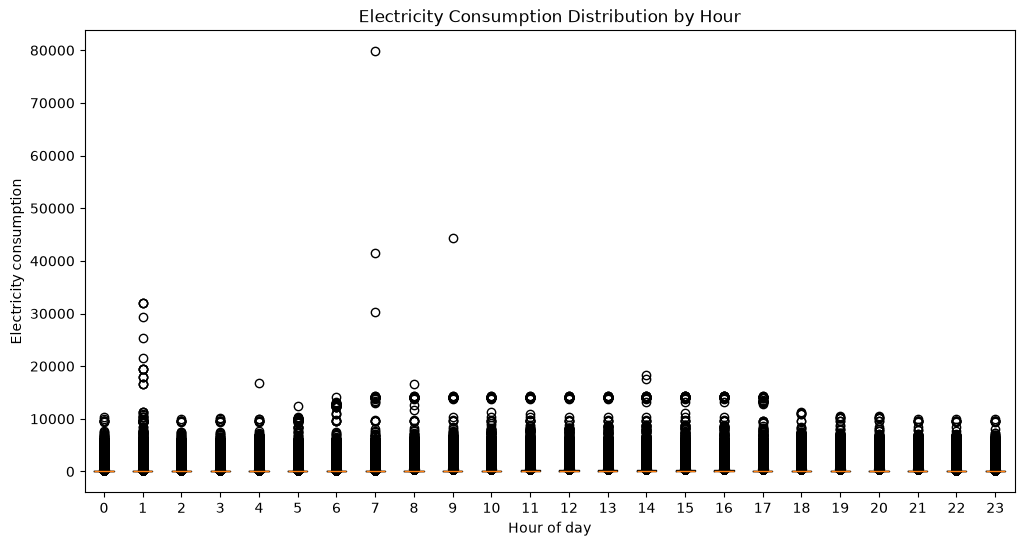

In [17]:
# Electricity consumption distribution by hour

hourly_data = []

for hour in range(24):
    values = electricity[electricity["hour"] == hour]["meter_reading"]
    hourly_data.append(values)

plt.figure(figsize=(12, 6))
plt.boxplot(hourly_data)
plt.xlabel("Hour of day")
plt.ylabel("Electricity consumption")
plt.title("Electricity Consumption Distribution by Hour")
plt.xticks(range(1, 25), range(24))
plt.show()

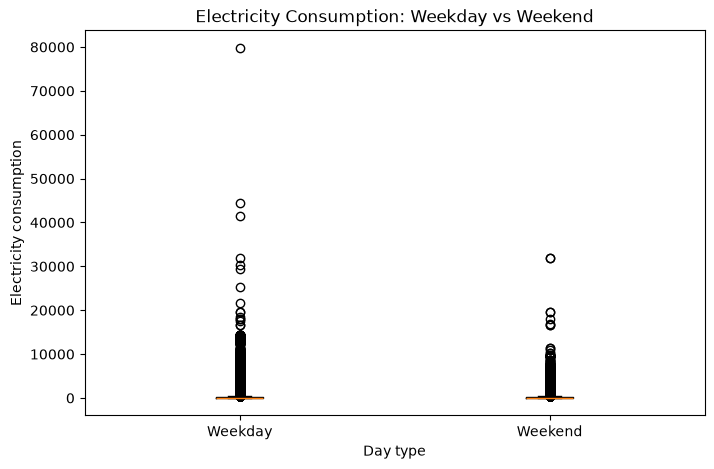

In [19]:
# Compare weekday and weekend electricity consumption

weekday_data = electricity[electricity["weekend"] == 0]["meter_reading"]
weekend_data = electricity[electricity["weekend"] == 1]["meter_reading"]
plt.figure(figsize=(8, 5))
plt.boxplot([weekday_data, weekend_data],tick_labels=["Weekday", "Weekend"])
plt.xlabel("Day type")
plt.ylabel("Electricity consumption")
plt.title("Electricity Consumption: Weekday vs Weekend")
plt.show()

## 9. Merge building and weather information

In [22]:
data = electricity.merge(building_metadata, on="building_id", how="left")

data = data.merge(weather_train, on=["site_id", "timestamp"], how="left")

print("Merged data shape:", data.shape)

Merged data shape: (12060910, 20)


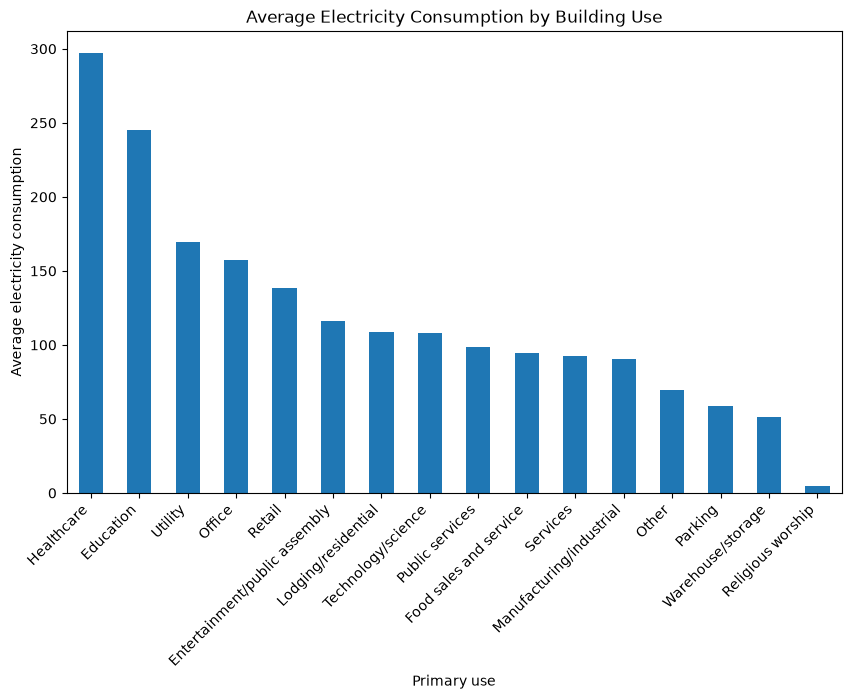

In [23]:
# Average electricity consumption by building type

building_type_average = (data.groupby("primary_use")["meter_reading"].mean().sort_values(ascending=False))
plt.figure(figsize=(10, 6))
building_type_average.plot(kind="bar")
plt.xlabel("Primary use")
plt.ylabel("Average electricity consumption")
plt.title("Average Electricity Consumption by Building Use")
plt.xticks(rotation=45, ha="right")
plt.show()

## 10. Check missing values after merging

In [24]:
missing = data.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

floor_count           9096083
year_built            6470035
cloud_coverage        5329652
precip_depth_1_hr     2513679
sea_level_pressure    1018383
wind_direction         678715
wind_speed              66795
dew_temperature         49091
air_temperature         47325
dtype: int64


## 11. Handle missing feature values

In [25]:
features = ["hour", "dayofweek", "month", "weekend", "air_temperature", "square_feet"]

# Check that the selected features exist
print("Features:", features)

# Show missing values before filling
print("Missing values before filling:")
print(data[features].isna().sum())

Features: ['hour', 'dayofweek', 'month', 'weekend', 'air_temperature', 'square_feet']
Missing values before filling:
hour                   0
dayofweek              0
month                  0
weekend                0
air_temperature    47325
square_feet            0
dtype: int64


In [26]:
# Fill missing numerical features with their median
for column in features:
    median_value = data[column].median()
    data[column] = data[column].fillna(median_value)

print("Missing values after filling:")
print(data[features].isna().sum())

Missing values after filling:
hour               0
dayofweek          0
month              0
weekend            0
air_temperature    0
square_feet        0
dtype: int64


### 11.1 Final data-quality check

In [27]:
print("Missing target:", data["meter_reading"].isna().sum())
print("Negative target values:", (data["meter_reading"] < 0).sum())

print("Duplicate building-timestamp-meter rows:", data.duplicated(subset=["building_id", "timestamp", "meter"]).sum())

print("Final modelling rows:", len(data))

Missing target: 0
Negative target values: 0
Duplicate building-timestamp-meter rows: 0
Final modelling rows: 12060910


## 12. Sort the data by time

In [28]:
data = data.sort_values("timestamp").reset_index(drop=True)

## 13. Train/validation split

We need labelled data to evaluate our models.

The official GEPIII `test.csv` does not contain the actual `meter_reading`, so we cannot use it to calculate MAE, RMSE or R².

Instead, we temporarily hold out the **last 20% of the labelled data** as a validation period.

This is preferable to a random split because a random split can mix future observations into the training data.

In [29]:
split_index = int(len(data) * 0.80)

train_data = data.iloc[:split_index].copy()
valid_data = data.iloc[split_index:].copy()

print("Training rows:", len(train_data))
print("Validation rows:", len(valid_data))

print("Training period:", train_data["timestamp"].min(), "to", train_data["timestamp"].max())
print("Validation period:", valid_data["timestamp"].min(), "to", valid_data["timestamp"].max())

Training rows: 9648728
Validation rows: 2412182
Training period: 2016-01-01 00:00:00 to 2016-10-20 07:00:00
Validation period: 2016-10-20 07:00:00 to 2016-12-31 23:00:00


## 14. Prepare model inputs

We use the same six simple features for all three models so that the comparison is fair.

The missing-value medians are calculated from the training period only and then applied to both training and validation data.

In [30]:
X_train = train_data[features].copy()
X_valid = valid_data[features].copy()

y_train = train_data["meter_reading"]
y_valid = valid_data["meter_reading"]

# Calculate medians only from the training data
train_medians = X_train.median()

for column in features:
    X_train[column] = X_train[column].fillna(train_medians[column])
    X_valid[column] = X_valid[column].fillna(train_medians[column])

print("Missing values in X_train:")
print(X_train.isna().sum())

print("Missing values in X_valid:")
print(X_valid.isna().sum())

Missing values in X_train:
hour               0
dayofweek          0
month              0
weekend            0
air_temperature    0
square_feet        0
dtype: int64
Missing values in X_valid:
hour               0
dayofweek          0
month              0
weekend            0
air_temperature    0
square_feet        0
dtype: int64


# 15. Build the models

### Base model: Linear Regression

### Proposed model 1: Random Forest

### Proposed model 2: Gradient Boosting

In [ ]:
# 1. Base Model: Linear Regression
base_model = LinearRegression()
base_model.fit(X_train, y_train)

base_pred = base_model.predict(X_valid)


# 2. Proposed Model: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_valid)


# 3. Proposed Model: Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_valid)

## 16. Compare the three models

In [ ]:
model_predictions = {"Linear Regression (Base)": base_pred, "Random Forest (Proposed)": rf_pred, "Gradient Boosting (Proposed)": gb_pred}

results = []

for model_name, predictions in model_predictions.items():
    mae = mean_absolute_error(y_valid, predictions)
    rmse = np.sqrt(mean_squared_error(y_valid, predictions))
    r2 = r2_score(y_valid, predictions)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))

### 16.1 Visual comparison

In [ ]:
plt.figure(figsize=(9, 5))

sample_size = min(1000, len(y_valid))
sample_index = np.arange(sample_size)

plt.plot(sample_index, y_valid.iloc[:sample_size].values, label="Actual")
plt.plot(sample_index, base_pred[:sample_size], label="Linear Regression")
plt.plot(sample_index, rf_pred[:sample_size], label="Random Forest")
plt.plot(sample_index, gb_pred[:sample_size], label="Gradient Boosting")

plt.xlabel("Validation observations")
plt.ylabel("Electricity consumption")
plt.title("Actual and Predicted Electricity Consumption")
plt.legend()
plt.show()

## 17. Select a proposed model for residual analysis

In [ ]:
rf_rmse = np.sqrt(mean_squared_error(y_valid, rf_pred))
gb_rmse = np.sqrt(mean_squared_error(y_valid, gb_pred))

if rf_rmse <= gb_rmse:
    chosen_model_name = "Random Forest"
    chosen_predictions = rf_pred
else:
    chosen_model_name = "Gradient Boosting"
    chosen_predictions = gb_pred

print("Model used for residual analysis:", chosen_model_name)

## 18. Calculate prediction residuals

In [ ]:
validation_results = valid_data[
    ["timestamp", "building_id", "site_id", "meter_reading"]
].copy()

validation_results["predicted"] = chosen_predictions
validation_results["residual"] = (
    validation_results["meter_reading"]
    - validation_results["predicted"]
)

validation_results["absolute_error"] = (
    validation_results["residual"].abs()
)

validation_results.head()

## 19. Simple residual-based anomaly detection

In [ ]:
residual_mean = validation_results["residual"].mean()
residual_std = validation_results["residual"].std()

upper_threshold = residual_mean + 3 * residual_std
lower_threshold = residual_mean - 3 * residual_std

validation_results["anomaly"] = (
    (validation_results["residual"] > upper_threshold) |
    (validation_results["residual"] < lower_threshold)
)

print("Number of flagged anomalies:", validation_results["anomaly"].sum())
print("Percentage flagged:", validation_results["anomaly"].mean() * 100)

## 20. Rank the most unusual observations

In [ ]:
top_anomalies = validation_results.sort_values(
    "absolute_error",
    ascending=False
).head(20)

top_anomalies

## 21. Inspect the residuals

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(validation_results["residual"], bins=50)
plt.axvline(upper_threshold, linestyle="--", label="Upper threshold")
plt.axvline(lower_threshold, linestyle="--", label="Lower threshold")
plt.xlabel("Residual")
plt.ylabel("Number of observations")
plt.title(f"Residual Distribution - {chosen_model_name}")
plt.legend()
plt.show()